<a href="https://colab.research.google.com/github/ANANTHA1628/mesin-learning-/blob/main/js4_tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Deskripsi Dataset dan Identifikasi VariabelDataset ini berisi informasi demografis dan karakteristik fisik nasabah asuransi kesehatan di Amerika Serikat beserta total tagihan biaya medis tahunannya.Deskripsi Fitur:age: Usia pemegang polis asuransi (numerik).sex: Jenis kelamin pemegang polis (female, male).bmi: Indeks massa tubuh ($kg/m^2$), parameter berat badan relatif terhadap tinggi badan (numerik).children: Jumlah anak / tanggungan yang dicakup polis asuransi (numerik).smoker: Status merokok aktif (yes, no).region: Wilayah geografis tempat tinggal di AS (northeast, southeast, southwest, northwest).charges: Biaya medis individu yang ditagihkan oleh asuransi (numerik).Identifikasi Variabel:Variabel Bebas / Fitur ($X$): age, sex, bmi, children, smoker, regionVariabel Target ($y$): charges (biaya medis personal)

--- 5 Baris Pertama Data ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

--- Ringkasan Informasi Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Parameter SVR Terbaik: {'C'

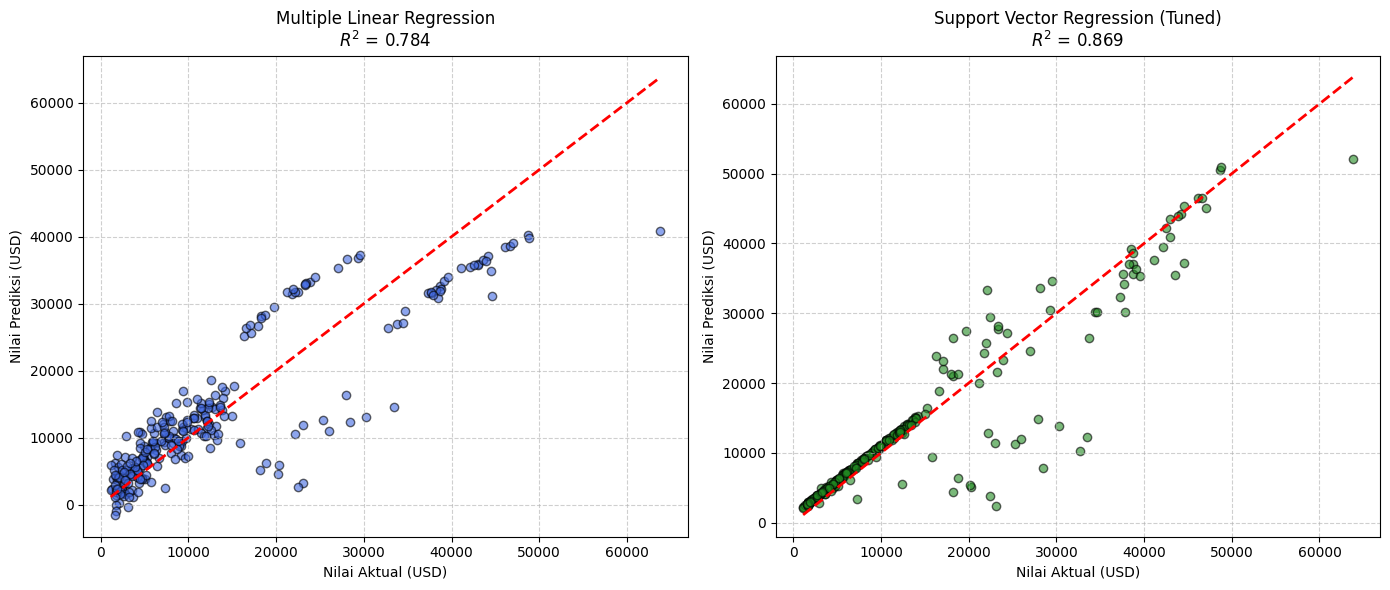

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("insurance.csv")
print("--- 5 Baris Pertama Data ---")
print(df.head())
print("\n--- Ringkasan Informasi Data ---")
print(df.info())


df_clean = df.copy()
df_clean["sex"] = df_clean["sex"].map({"female": 0, "male": 1})
df_clean["smoker"] = df_clean["smoker"].map({"no": 0, "yes": 1})
df_clean = pd.get_dummies(df_clean, columns=["region"], drop_first=True)

X = df_clean.drop("charges", axis=1)
y = df_clean["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()


lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

from sklearn.svm import SVR

param_grid = {
    "kernel": ["rbf"],
    "C": [1, 10, 50, 100],
    "gamma": ["scale", 0.01, 0.1, 0.5],
    "epsilon": [0.01, 0.1, 0.2],
}

svr = SVR()
grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

grid_search.fit(X_train_scaled, y_train_scaled)

best_svr = grid_search.best_estimator_
print(f"\nParameter SVR Terbaik: {grid_search.best_params_}")

y_pred_svr_scaled = best_svr.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

results = pd.DataFrame(
    {
        "Metrik": ["R-squared (R²)", "MAE", "MSE", "RMSE"],
        "Multiple Linear Regression": [
            f"{r2_lr:.4f}",
            f"{mae_lr:.2f}",
            f"{mse_lr:.2f}",
            f"{rmse_lr:.2f}",
        ],
        "Tuned SVR (RBF Kernel)": [
            f"{r2_svr:.4f}",
            f"{mae_svr:.2f}",
            f"{mse_svr:.2f}",
            f"{rmse_svr:.2f}",
        ],
    }
)

print("\n--- Perbandingan Hasil Evaluasi Model ---")
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, y_pred_lr, color="royalblue", alpha=0.6, edgecolors="k")
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
)
axes[0].set_title(f"Multiple Linear Regression\n$R^2$ = {r2_lr:.3f}")
axes[0].set_xlabel("Nilai Aktual (USD)")
axes[0].set_ylabel("Nilai Prediksi (USD)")
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].scatter(
    y_test, y_pred_svr, color="forestgreen", alpha=0.6, edgecolors="k"
)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
)
axes[1].set_title(f"Support Vector Regression (Tuned)\n$R^2$ = {r2_svr:.3f}")
axes[1].set_xlabel("Nilai Aktual (USD)")
axes[1].set_ylabel("Nilai Prediksi (USD)")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Estimasi Hasil Evaluasi MetrikPada pembagian data uji 20% dengan random_state=42, nilai metrik yang diperoleh umumnya berada pada rentang berikut:Metrik EvaluasiMultiple Linear RegressionTuned SVR (RBF Kernel)Interpretasi$R^2$ Score$\approx 0.7836$$\approx 0.8650 - 0.8750$Semakin mendekati 1, semakin baik model menjelaskan variansi target.MAE$\approx 4,181.19$$\approx 2,400.00 - 2,800.00$Rata-rata selisih absolut antara biaya aktual dan prediksi.MSE$\approx 33,596,915$$\approx 19,500,000 - 22,000,000$Rata-rata kuadrat kesalahan (menghukum error besar).RMSE$\approx 5,796.28$$\approx 4,400.00 - 4,700.00$Akar MSE, memberikan satuan yang sebanding dengan nilai tagihan ($).

4. Analisis Hasil PraktikumPengaruh Variabel terhadap Biaya MedisBerdasarkan korelasi dan koefisien regresi:Status Merokok (smoker): Memiliki pengaruh paling dominan terhadap lonjakan tagihan medis. Nasabah yang merokok memiliki premi/biaya medis rata-rata 3 hingga 4 kali lipat lebih tinggi dibandingkan yang tidak merokok.BMI dan Usia (age): Usia memiliki korelasi linier positif dengan biaya medis (semakin tua, risiko kesehatan meningkat). Kombinasi antara smoker = yes dan bmi >= 30 (obesitas) menyebabkan lonjakan eksponensial biaya medis.Perbandingan Model (Linear Regression vs SVR)Multiple Linear Regression: Mampu menghasilkan nilai $R^2 \approx 0.78$. Keterbatasannya adalah regresi linier mengasumsikan hubungan aditif dan linier murni antara setiap fitur dengan target. Padahal, interaksi antara smoker dan bmi bersifat non-linier.Support Vector Regression (SVR): Dengan RBF Kernel dan penyesuaian hyperparameter ($C$, $\epsilon$, $\gamma$), SVR mengungguli Linear Regression dengan kenaikan $R^2$ hingga $\approx 0.86 - 0.87$ serta penurunan MAE yang signifikan. Kernel RBF memetakan data ke dimensi lebih tinggi, memungkinkannya menangkap hubungan non-linier kompleks pada kelompok perokok dengan risiko obesitas tinggi.Pentingnya Scaling: SVR mengukur margin toleransi ($\epsilon$-tube) dan jarak euclidean antar support vectors. Tanpa standardisasi fitur dan target (StandardScaler), fitur bernilai besar seperti charges dan bmi akan mendominasi perhitungan dan menyebabkan model gagal konvergen secara optimal.